# XLEAP — scratch / exploration

Ad-hoc investigation kept out of the clean `XLEAP_detector.ipynb`. Run from the repo root or from `tests/` (the setup cell fixes the path either way). Cells that hit the live archiver (`meme`) only work on the SLAC network (dev-epics).

In [7]:
import os, sys

# repo root importable + working dir, whether launched from repo root or tests/
_root = os.getcwd()
if not os.path.isdir(os.path.join(_root, 'taper')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
os.chdir(_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from taper import (
    SnapshotStore, DEFAULT_LINE as LINE, xleap_timeline, timeline_frame,
    gamma_from_momentum_gev, taper_mev_per_fs,
)

store = SnapshotStore.from_csv('snapshots.csv')
df = timeline_frame(xleap_timeline(store, line=LINE)).sort_index()
mom = store.series(LINE.momentum_pv).reindex(df.index)
print(f'line={LINE.name}  snapshots={len(df)}  max taper={df["taper"].max():.1f} MeV/fs')

line=SXR  snapshots=1250  max taper=426.2 MeV/fs


## K vs z at a chosen snapshot

z is derived from the undulator device number (step 100/slot) so a missing segment shows a real gap. `SEGMENT_PITCH_M` is approximate — use the MEME model Z-positions for exact z.

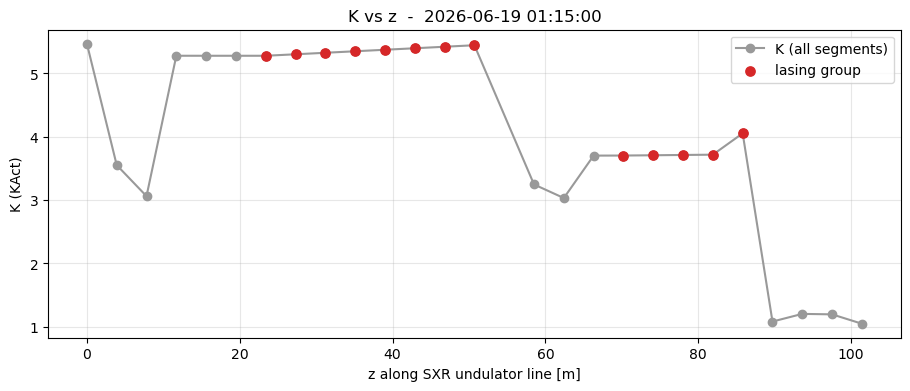

In [8]:
TIME = '2026-06-19 01:15:00'   # snapshot to plot; None -> first bin
SEGMENT_PITCH_M = 3.9          # approx center-to-center along the SXR line

from taper.detect import lasing_mask, DetectionParams
kv = store.wide_values(LINE.kact_pattern)
t = kv.index[0] if TIME is None else pd.Timestamp(TIME)
ks = kv.loc[t]
nums = [int(c) for c in ks.index]
z = [(n - nums[0]) / 100.0 * SEGMENT_PITCH_M for n in nums]
mask = lasing_mask(kv, DetectionParams()).loc[t]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(z, ks.values, '-o', color='0.6', label='K (all segments)')
las = [(z[i], ks.iloc[i]) for i in range(len(ks)) if bool(mask.iloc[i])]
if las:
    ax.scatter(*zip(*las), color='tab:red', zorder=3, s=45, label='lasing group')
ax.set_xlabel('z along SXR undulator line [m]'); ax.set_ylabel('K (KAct)')
ax.set_title(f'K vs z  -  {t}'); ax.grid(alpha=0.3); ax.legend(); plt.show()

## Raw DMPS trace around a spike  (needs `meme`, SLAC network)

Pinpoints whether an off-nominal energy reading was a one-sample glitch or a magnet standardization (oscillation). Times are UTC to match the CSV; pass tz-aware datetimes so `meme` doesn't reinterpret them as Pacific.

BEND:DMPS:400:BACT  raw samples=2838  min=0.027  max=15.714 GeV/c


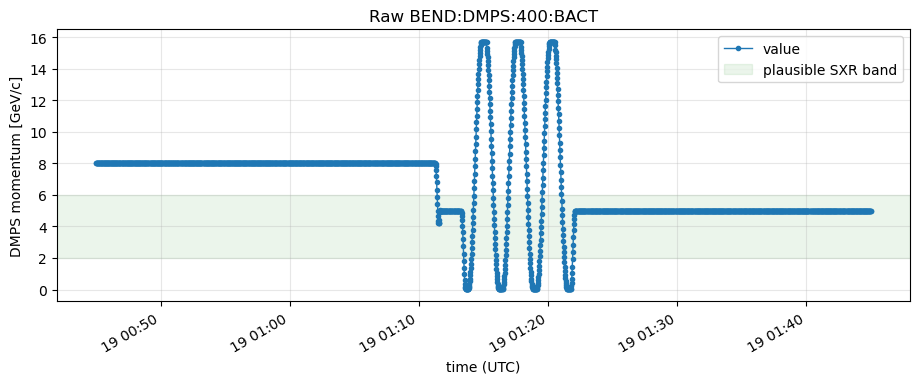

In [14]:
from datetime import datetime, timezone
import meme.archive

PV = LINE.momentum_pv
t0 = datetime(2026, 6, 19, 0, 45, tzinfo=timezone.utc)
t1 = datetime(2026, 6, 19, 1, 45, tzinfo=timezone.utc)
raw = meme.archive.get_dataframe(PV, from_time=t0, to_time=t1)
raw.index = raw.index.tz_convert('UTC')
s = raw[raw.columns[0]]
print(f'{PV}  raw samples={len(s)}  min={s.min():.3f}  max={s.max():.3f} GeV/c')

ax = s.plot(marker='o', ms=3, lw=1, figsize=(11, 4))
ax.axhspan(2, 6, color='green', alpha=0.08, label='plausible SXR band')
ax.set_ylabel('DMPS momentum [GeV/c]'); ax.set_xlabel('time (UTC)')
ax.set_title(f'Raw {PV}'); ax.grid(alpha=0.3); ax.legend(); plt.show()

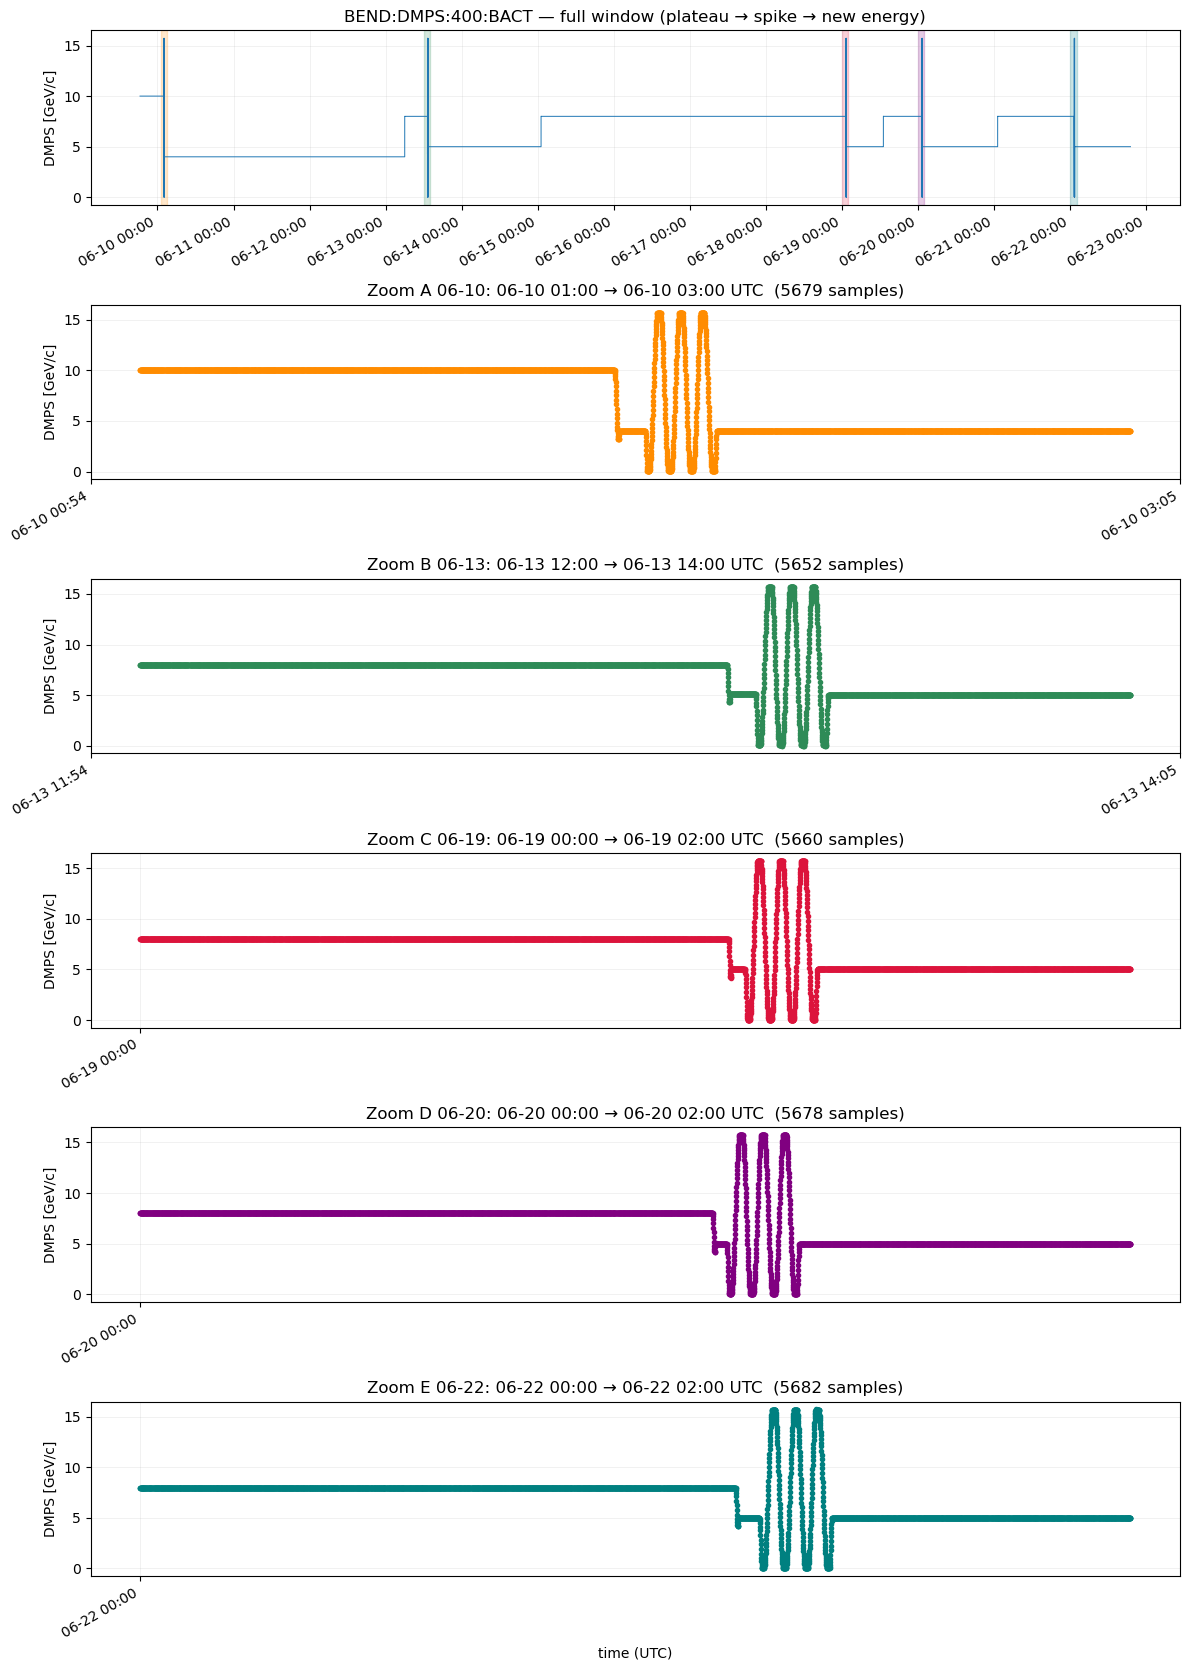

In [ ]:
from datetime import datetime, timezone
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import meme.archive

def utc(y, m, d, hh, mm=0):
    return datetime(y, m, d, hh, mm, tzinfo=timezone.utc)

PV = LINE.momentum_pv
t0 = utc(2026, 6, 9, 18, 30)
t1 = utc(2026, 6, 22, 19, 0)

raw = meme.archive.get_dataframe(PV, from_time=t0, to_time=t1)
raw.index = raw.index.tz_convert('UTC')
s = raw[raw.columns[0]]

# --- five zoom windows: (name, start, end) ---
windows = [
    ('A 06-10', utc(2026, 6, 10, 1, 0),  utc(2026, 6, 10, 3, 0)),
    ('B 06-13', utc(2026, 6, 13, 12, 0), utc(2026, 6, 13, 14, 0)),   # halfway through the 13th
    ('C 06-19', utc(2026, 6, 19, 0, 0),  utc(2026, 6, 19, 2, 0)),
    ('D 06-20', utc(2026, 6, 20, 0, 0),  utc(2026, 6, 20, 2, 0)),
    ('E 06-22', utc(2026, 6, 22, 0, 0),  utc(2026, 6, 22, 2, 0)),
]
colors = ['darkorange', 'seagreen', 'crimson', 'purple', 'teal']

fig, axes = plt.subplots(1 + len(windows), 1, figsize=(12, 2.8 * (1 + len(windows))))
ax_full, zoom_axes = axes[0], axes[1:]

# top: full contet — shade each window in its matching color
ax_full.plot(s.index, s.values, lw=0.7, color='#1f77b4', rasterized=True)
for (name, zlo, zhi), c in zip(windows, colors):
    ax_full.axvspan(zlo, zhi, color=c, alpha=0.20)
ax_full.set_ylabel('DMPS [GeV/c]')
ax_full.set_title(f'{PV} — full window (plateau → spike → new energy)')
ax_full.grid(alpha=0.25, lw=0.5)

# one zoom panel per window
for ax, (name, zlo, zhi), c in zip(zoom_axes, windows, colors):
    z = s.loc[zlo:zhi]
    ax.plot(z.index, z.values, marker='o', ms=3, lw=1, color=c)
    ax.set_ylabel('DMPS [GeV/c]')
    ax.set_title(f'Zoom {name}: {zlo:%m-%d %H:%M} → {zhi:%m-%d %H:%M} UTC  ({len(z)} samples)')
    ax.grid(alpha=0.25, lw=0.5)
zoom_axes[-1].set_xlabel('time (UTC)')

# 24-hour ticks WITH labels on every panel
for ax in axes:
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    for lbl in ax.get_xticklabels():
        lbl.set_rotation(30); lbl.set_ha('right')

fig.tight_layout()
plt.show()

## Elevated-taper investigation

Where the big tapers come from: off-nominal / unsteady beam energy inflated by the gamma^3 scaling. Every high point should trace back to the energy, not the K-ramp.

In [10]:
hi = df[df['taper'] > 100].copy()
hi['mom_GeVc'] = mom.reindex(hi.index).round(3)
hi['gamma'] = gamma_from_momentum_gev(hi['mom_GeVc'].to_numpy()).round(0)
display(hi[['taper', 'mom_GeVc', 'gamma', 'n_und']].sort_values('taper', ascending=False))

# gamma^3 counterfactual for the worst point
worst = df['taper'].idxmax()
kv = store.wide_values(LINE.kact_pattern)
from taper.detect import lasing_kvals, first_group, DetectionParams
grp = first_group(lasing_kvals(kv, DetectionParams()).loc[worst])
dK = float(grp.diff().dropna().median()); K = float(grp.iloc[0])
p = float(mom.loc[worst])
print(f'worst {worst}: K={K:.3f} dK={dK:.5f} mom={p:.3f} GeV/c')
for pn in (4.3, 5.0):
    g = float(gamma_from_momentum_gev(pn))
    print(f'  same dK,K at {pn} GeV/c -> {float(taper_mev_per_fs(dK, K, g)):.1f} MeV/fs')

,taper,mom_GeVc,gamma,n_und
datetime,,,,
2026-06-22 09:00:00,426.223861,5.0,9785.0,5
2026-06-13 06:45:00,151.396770,8.0,15656.0,8
2026-06-13 07:30:00,151.282340,8.0,15656.0,8
2026-06-13 06:30:00,151.268626,8.0,15656.0,8
2026-06-13 07:00:00,151.268018,8.0,15656.0,8
2026-06-13 07:15:00,151.263900,8.0,15656.0,8
2026-06-13 07:45:00,151.195549,8.0,15656.0,8
2026-06-13 06:15:00,151.156662,8.0,15656.0,8
2026-06-22 15:15:00,125.967802,5.0,9785.0,16


worst 2026-06-22 09:00:00: K=3.032 dK=0.10399 mom=5.000 GeV/c
  same dK,K at 4.3 GeV/c -> 271.1 MeV/fs
  same dK,K at 5.0 GeV/c -> 426.2 MeV/fs


## Energy-stability gate check  (after a re-fetch)

Once `snapshots.csv` is re-fetched with the `spread` column, the gate clears energy-unsteady bins (`taper` NaN, `energy_unsteady` True). On legacy data (no spread) the gate is dormant and this shows 0 cleared.

In [11]:
n_unsteady = int(df['energy_unsteady'].sum())
print(f'energy_unsteady bins: {n_unsteady}   max taper: {df["taper"].max():.1f} MeV/fs')
if n_unsteady:
    display(df[df['energy_unsteady']][['taper', 'n_und', 'energy_unsteady']]
            .assign(mom_GeVc=mom.round(3)))
else:
    print('(gate dormant - re-fetch with the current code to populate spread)')

energy_unsteady bins: 13   max taper: 426.2 MeV/fs


,taper,n_und,energy_unsteady,mom_GeVc
datetime,,,,
2026-06-10 01:45:00,NaN,0,True,10.000
2026-06-10 02:00:00,NaN,0,True,4.000
2026-06-13 06:00:00,NaN,0,True,4.000
2026-06-13 13:00:00,NaN,0,True,8.000
2026-06-13 13:15:00,NaN,0,True,0.027
2026-06-15 01:00:00,NaN,0,True,5.000
2026-06-19 01:00:00,NaN,0,True,8.000
2026-06-19 01:15:00,NaN,0,True,15.703
2026-06-19 13:00:00,NaN,0,True,5.000
